# Labb 2 - CNN

 Texten har efterbehandlats med llm i inledningen för en teknisk rapport.

# Introduktion

Denna rapport undersöker hur ett neuralt nätverk kan tolkas med hjälp av Class Activation Mapping (CAM). Målet är att förstå vilka delar av en bild som påverkar modellens prediktioner.

# Metod

I denna uppgift används modellen ResNet18 med för tränade vikter. Modellen valdes eftersom den är relativt enkel att använda och redan är tränad på datasetet ImageNet, som innehåller 1000 olika klasser.

För att analysera modellen används metoden LayerCAM från biblioteket TorchCAM. LayerCAM används för att skapa attribution maps, som visar vilka delar av bilden modellen fokuserar på när den gör en prediktion. Metoden kombinerar information från modellens lager och gradienter för att markera de områden i bilden som påverkar resultatet mest.

# Resultat

In [1]:
from Labb2_CNN import ResnetVisualizer

visualizer = ResnetVisualizer()

# Golden retriever (hund)

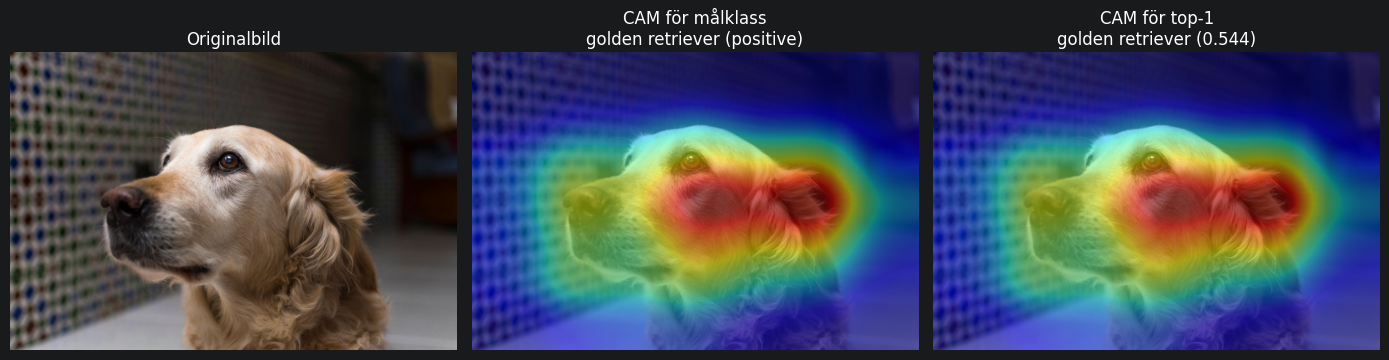

Top-5 prediktioner:
1. golden retriever (0.5436)
2. English setter (0.1705)
3. cocker spaniel (0.0925)
4. Labrador retriever (0.0509)
5. Afghan hound (0.0249)
Tolkning: Detta är en positiv bild för golden retriever. CAM för målklassen bör främst markera objektet.


In [2]:
visualizer.fit_visualize_image(
    img_path="images/golden_positive.jpg",
    target_class="golden retriever",
    example_type="positive",
    top_k=5,
    layer=4
)

# Analys:
Den positiva bilden innehåller en golden retriever. CAM bör främst markera hunden, särskilt huvud, ansikte eller päls. Det är rimligt eftersom dessa delar är viktiga för att känna igen klassen.

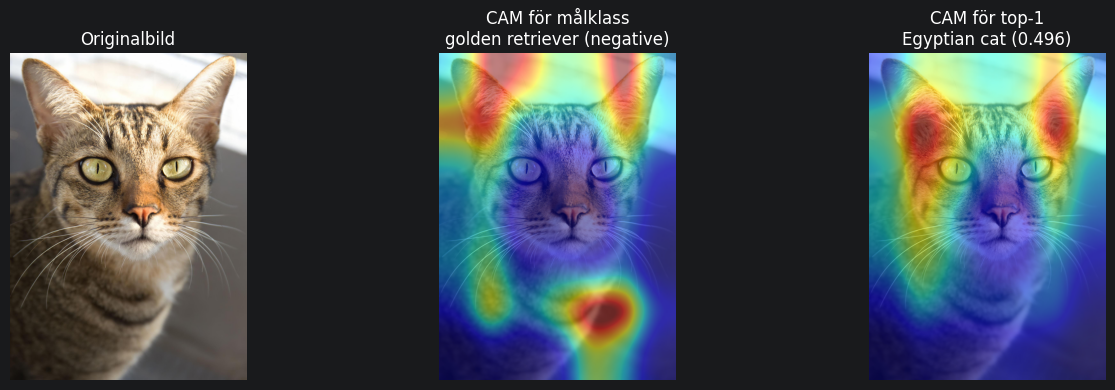

Top-5 prediktioner:
1. Egyptian cat (0.4956)
2. tabby (0.3336)
3. tiger cat (0.1641)
4. lynx (0.0038)
5. plastic bag (0.0004)
Tolkning: Detta är en negativ bild för golden retriever. CAM kan vara svagare eller mer utspridd eftersom målklassen inte finns i bilden.


In [3]:
visualizer.fit_visualize_image(
    img_path="images/golden_negative.jpg",
    target_class="golden retriever",
    example_type="negative",
    top_k=5,
    layer=4
)

# Analys:
Den negativa bilden innehåller inte en golden retriever. Därför är det rimligt om CAM är svagare, mer utspridd eller markerar delar som bara liknar päls eller djurform.

# Tabby (katt)

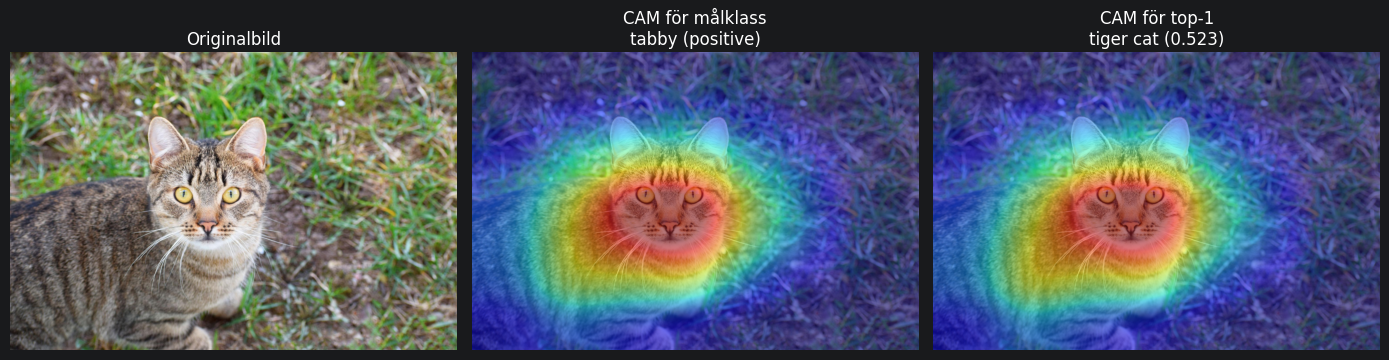

Top-5 prediktioner:
1. tiger cat (0.5225)
2. tabby (0.3960)
3. Egyptian cat (0.0612)
4. lynx (0.0065)
5. bucket (0.0011)
Tolkning: Detta är en positiv bild för tabby. CAM för målklassen bör främst markera objektet.


In [4]:
visualizer.fit_visualize_image(
    img_path="images/tabby_positive.jpg",
    target_class="tabby",
    example_type="positive",
    top_k=5,
    layer=4
)

# Analys:
Den positiva bilden innehåller en tabby-katt. CAM bör främst markera kattens ansikte och pälsmönster eftersom detta är viktiga kännetecken för klassen.

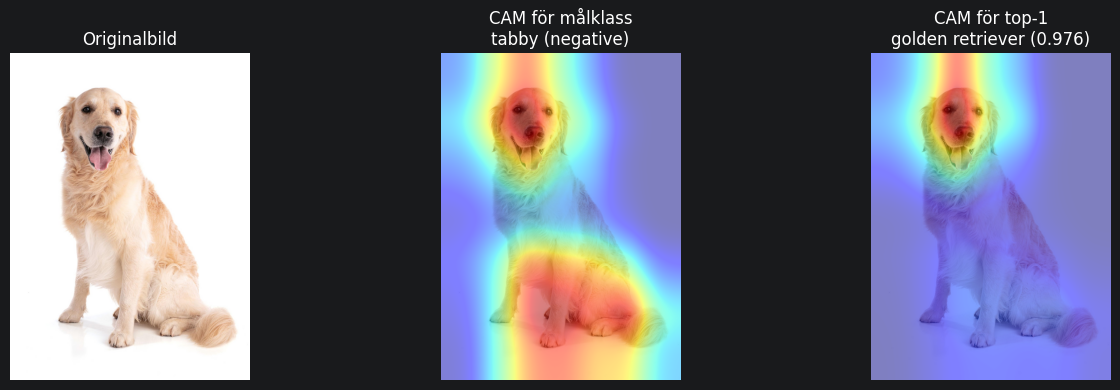

Top-5 prediktioner:
1. golden retriever (0.9757)
2. chow (0.0078)
3. kuvasz (0.0065)
4. Labrador retriever (0.0027)
5. cocker spaniel (0.0022)
Tolkning: Detta är en negativ bild för tabby. CAM kan vara svagare eller mer utspridd eftersom målklassen inte finns i bilden.


In [5]:
visualizer.fit_visualize_image(
    img_path="images/tabby_negative.jpg",
    target_class="tabby",
    example_type="negative",
    top_k=5,
    layer=4
)

# Analys:
Den negativa bilden innehåller inte en tabby-katt. Om CAM ändå markerar päls eller ansikte är det rimligt, eftersom hundar och katter kan ha vissa liknande visuella drag.

# Sports car (personbil)

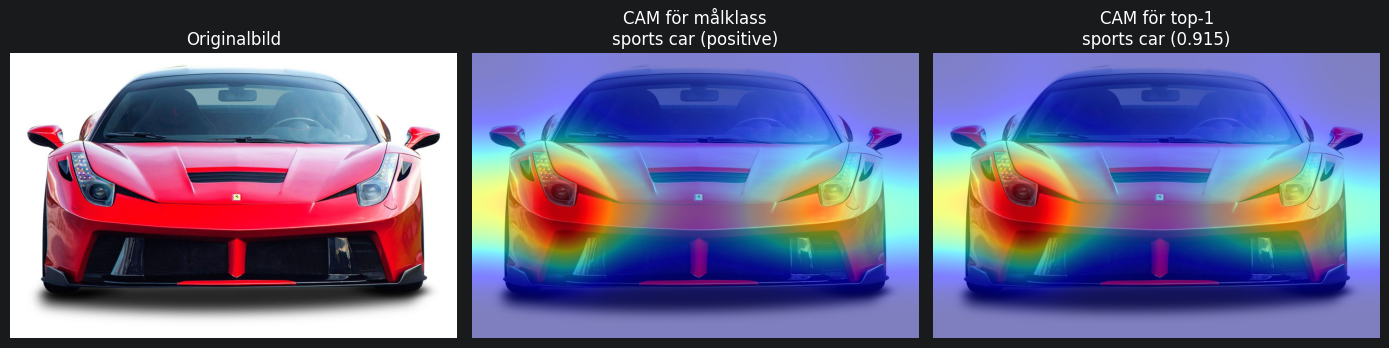

Top-5 prediktioner:
1. sports car (0.9150)
2. grille (0.0376)
3. racer (0.0182)
4. crash helmet (0.0147)
5. convertible (0.0055)
Tolkning: Detta är en positiv bild för sports car. CAM för målklassen bör främst markera objektet.


In [6]:
visualizer.fit_visualize_image(
    img_path="images/sportscar_positive.jpg",
    target_class="sports car",
    example_type="positive",
    top_k=5,
    layer=4
)

# Analys:
Den positiva bilden innehåller en sportbil. CAM bör främst markera bilens form, front, strålkastare eller kaross.

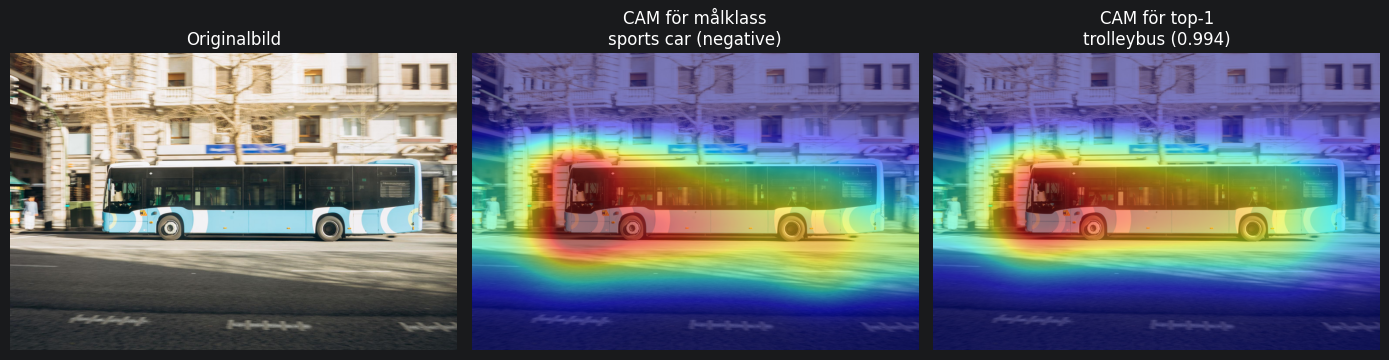

Top-5 prediktioner:
1. trolleybus (0.9938)
2. minibus (0.0035)
3. streetcar (0.0025)
4. police van (0.0001)
5. passenger car (0.0000)
Tolkning: Detta är en negativ bild för sports car. CAM kan vara svagare eller mer utspridd eftersom målklassen inte finns i bilden.


In [7]:
visualizer.fit_visualize_image(
    img_path="images/sportscar_negative.jpg",
    target_class="sports car",
    example_type="negative",
    top_k=5,
    layer=4
)

# Analys:
Den negativa bilden innehåller en buss. Eftersom en buss också är ett fordon kan CAM ibland markera fordonsdelar, men aktiveringen bör inte vara lika tydlig som för sportbilen.

# Logit-analys

In [8]:
visualizer.fit_image(
    img_path="images/golden_positive.jpg",
    target_class="golden retriever",
    top_k=5,
    layer=4
)

visualizer.print_logit_analysis(top_k=10)

Logit-analys:
1. golden retriever | logit = 13.1236
2. English setter | logit = 11.9642
3. cocker spaniel | logit = 11.3524
4. Labrador retriever | logit = 10.7553
5. Afghan hound | logit = 10.0392
6. Saluki | logit = 9.9859
7. Irish setter | logit = 9.5915
8. Sussex spaniel | logit = 9.0743
9. Brittany spaniel | logit = 8.8790
10. flat-coated retriever | logit = 8.8048


# Tolkning:
Om flera hundraser får höga logit värden är det rimligt. Det betyder att modellen ser visuella drag som liknar flera olika hundklasser, exempel päls, huvudform och kropp osv.

# Diskussion/resultat

Resultaten visar att modellen oftast fokuserar på relevanta delar av bilderna. I de positiva exemplen markeras objekten tydligt, exempel hundens ansikte eller bilens form, vilket tyder på att modellen använder rimliga visuella mönster.
I de negativa exemplen blir aktiveringen mer utspridd. I vissa fall markeras delar som liknar målklassen, exempel päls, fordonsdelar, vilket visar att modellen reagerar på likheter mellan olika objekt.

Logit analysen visar att flera liknande klasser kan få höga värden. Detta är rimligt eftersom många klasser liknar varandra visuellt.

Summerat så fungerar modellen bra på tydliga exempel, men påverkas av visuella likheter mellan dom olika bilderna.